# 05 — Evaluation, Threshold Tuning & Interpretation

**Goal:** measure the tuned model on the untouched test set, choose the
operating threshold from business economics, and explain *why* the model
predicts what it predicts.

The test set was created by a stratified split before any model saw the data
and is used exactly once — here.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

In [2]:
from src.evaluation import compute_feature_importance, evaluate_model
from src.inference import load_artifact
from src.utils import load_config

config = load_config()
artifact = load_artifact()
model, threshold = artifact["model"], artifact["threshold"]

test = pd.read_csv(ROOT / config["data"]["test_path"])
X_test, y_test = test[artifact["input_columns"]], test["churn_value"]
print(f"model: {artifact['model_name']}   tuned threshold: {threshold:.2f}")

2026-07-31 09:39:52,866 | src.inference | INFO | Loaded logistic_regression artifact trained at 2026-07-31T04:07:05+00:00


model: logistic_regression   tuned threshold: 0.29


## Default vs tuned threshold

A missed churner costs the remaining lifetime value; a wasted retention offer
costs a small discount. Because these costs are asymmetric, the threshold was
tuned to maximise **F2** (recall weighted 2× over precision) on *out-of-fold
training predictions* — never on the test set, because the threshold is a
model parameter like any other.

In [3]:
results = pd.DataFrame([
    {"setting": "default 0.50", **evaluate_model(model, X_test, y_test, 0.5)},
    {"setting": f"tuned {threshold:.2f}", **evaluate_model(model, X_test, y_test, threshold)},
]).set_index("setting").drop(columns=["confusion_matrix"])
results.round(4)

2026-07-31 09:39:52,910 | src.evaluation | INFO | Test metrics @0.50: {'threshold': 0.5, 'accuracy': 0.7494677075940384, 'precision': 0.5183887915936952, 'recall': 0.7914438502673797, 'f1': 0.6264550264550265, 'f2': 0.7160135462022255, 'roc_auc': 0.8490221912216798, 'avg_precision': 0.6441616669496883}


2026-07-31 09:39:52,929 | src.evaluation | INFO | Test metrics @0.29: {'threshold': 0.29000000000000004, 'accuracy': 0.6607523066004258, 'precision': 0.4341772151898734, 'recall': 0.9171122994652406, 'f1': 0.5893470790378007, 'f2': 0.7502187226596675, 'roc_auc': 0.8490221912216798, 'avg_precision': 0.6441616669496883}


,threshold,accuracy,precision,recall,f1,f2,roc_auc,avg_precision
setting,,,,,,,,
default 0.50,0.50,0.7495,0.5184,0.7914,0.6265,0.7160,0.849,0.6442
tuned 0.29,0.29,0.6608,0.4342,0.9171,0.5893,0.7502,0.849,0.6442


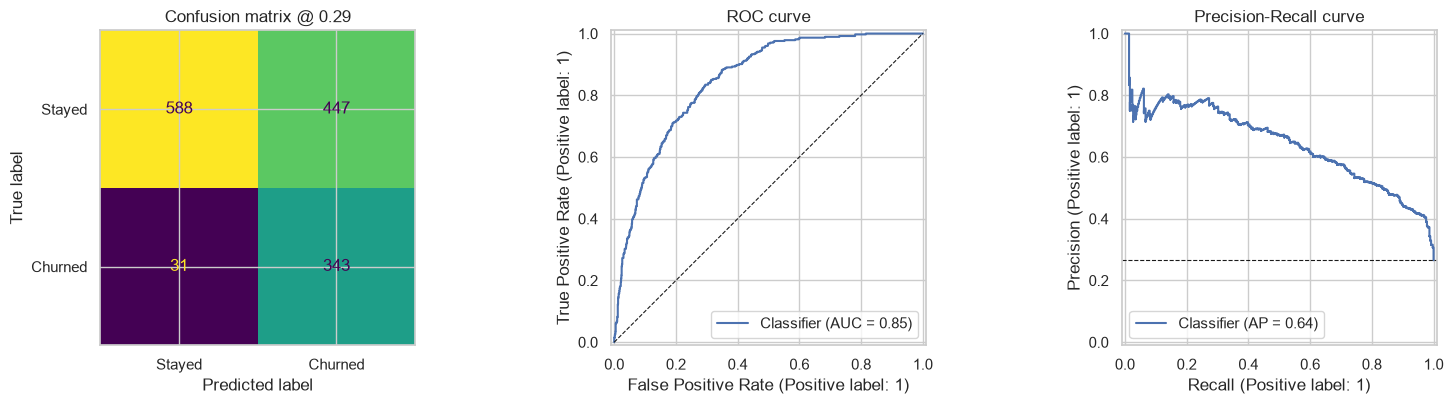

In [4]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay, confusion_matrix

proba = model.predict_proba(X_test)[:, 1]
pred = (proba >= threshold).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                       display_labels=["Stayed", "Churned"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"Confusion matrix @ {threshold:.2f}")
RocCurveDisplay.from_predictions(y_test, proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[1].set_title("ROC curve")
PrecisionRecallDisplay.from_predictions(y_test, proba, ax=axes[2])
axes[2].axhline(y_test.mean(), color="k", ls="--", lw=0.8)
axes[2].set_title("Precision-Recall curve")
fig.tight_layout()
plt.show()

## Interpretation — permutation importance

Permutation importance runs on the **whole pipeline with raw input columns**,
so importance lands on business-level features (not one-hot dummies): shuffle
one column, measure how much ROC-AUC drops, repeat 10×.

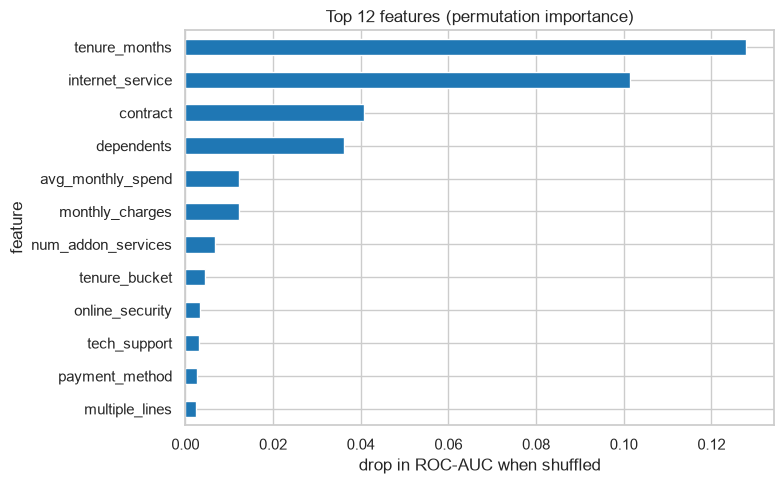

,feature,importance_mean,importance_std
0,tenure_months,0.127874,0.003909
1,internet_service,0.101379,0.010391
2,contract,0.040733,0.004131
3,dependents,0.036194,0.005731
4,avg_monthly_spend,0.012251,0.003274
5,monthly_charges,0.012173,0.003235
6,num_addon_services,0.006778,0.001970
7,tenure_bucket,0.004454,0.001560
8,online_security,0.003262,0.001350
9,tech_support,0.003126,0.001802


In [5]:
importance = compute_feature_importance(model, X_test, y_test)
top = importance.head(12).iloc[::-1]
ax = top.plot.barh(x="feature", y="importance_mean", xerr=importance.head(12).iloc[::-1]["importance_std"],
                   legend=False, figsize=(8, 5), color="tab:blue")
ax.set_xlabel("drop in ROC-AUC when shuffled")
ax.set_title("Top 12 features (permutation importance)")
plt.tight_layout()
plt.show()
importance.head(12)

## SHAP (optional deep-dive)

SHAP attributes each individual prediction to feature contributions — useful
for telling the retention team *why this specific customer* is at risk.

Background dataset has 1409 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1409 when initializing the masker.


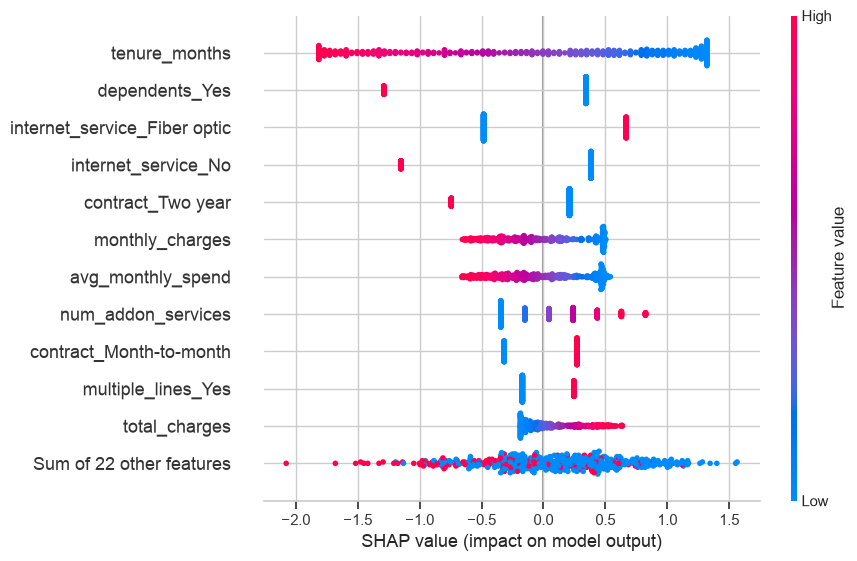

In [6]:
try:
    import shap

    pre = model.named_steps["preprocessor"]
    est = model.named_steps["model"]
    Xt = pre.transform(X_test)
    Xt = Xt.toarray() if hasattr(Xt, "toarray") else Xt
    Xt = pd.DataFrame(Xt, columns=pre.get_feature_names_out())

    explainer = shap.Explainer(est, Xt)
    shap_values = explainer(Xt[:500])
    shap.plots.beeswarm(shap_values, max_display=12)
except Exception as exc:  # SHAP is optional; never break the notebook
    print(f"SHAP skipped: {exc}")

## Reading the results for the business

* The model ranks churners far better than chance (see ROC-AUC above); at the
  tuned threshold it catches the large majority of churners at the cost of
  some wasted offers — the trade the economics favour.
* Top drivers align with EDA: **contract type, tenure, monthly charges,
  internet service** — the model learned the story the data told, which is
  exactly the consistency check interviewers look for.
* Serialized artifact (`models/churn_model.joblib`) bundles the pipeline,
  threshold and metadata; the Streamlit app in `app/` consumes it.